# Assignment Sesi 20
Nama: Faraday Barr Fatahillah

**INSTRUKSI**\
Anda adalah data analyst di sebuah bank. Tim marketing meminta segmentasi pelanggan kartu kredit berdasarkan pola penggunaan, untuk menentukan jenis promosi yang sesuai bagi masing-masing kelompok. Dataset berisi 18 fitur perilaku penggunaan kartu kredit dari sekitar 9.000 pelanggan aktif.

Dataset: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Task 1 — Persiapan Data dan EDA Singkat**
1. Load dataset, hapus kolom CUST_ID (bukan fitur), dan tangani missing value pada kolom MINIMUM_PAYMENTS dan CREDIT_LIMIT dengan median.
2. Standarisasi seluruh fitur menggunakan StandardScaler
3. Buat heatmap korelasi antar fitur. Identifikasi 3 pasangan fitur dengan korelasi tertinggi dan catat di markdown cell.

In [46]:
#Task 1.1
df = pd.read_csv('CC GENERAL.csv')

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [47]:
df = df.drop(columns='CUST_ID')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT_LIMIT     

In [48]:
df.isna().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_TRX                         0
PAYMENTS                              0
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [49]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].median()

df.isna().sum().sort_values(ascending=False)

CREDIT_LIMIT                        1
BALANCE                             0
BALANCE_FREQUENCY                   0
ONEOFF_PURCHASES                    0
PURCHASES                           0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
INSTALLMENTS_PURCHASES              0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [50]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].median()

df.isna().sum().sort_values(ascending=False)

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [51]:
#Task 1.2
scaler = StandardScaler()

data_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(data_scaled, columns=df.columns)

df_scaled.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8.950000e+03,8.950000e+03,8950.000000,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8950.0,8.950000e+03,8950.0,8950.000000,8.950000e+03
mean,8.891708e-17,2.286439e-16,0.000000,3.175610e-17,2.540488e-17,1.016195e-16,-1.841854e-16,-8.891708e-17,4.604634e-17,5.557317e-17,-2.540488e-17,-2.540488e-17,0.0,-3.810732e-17,0.0,0.000000,2.794537e-16
std,1.000056e+00,1.000056e+00,1.000056,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,0.0,1.000056e+00,0.0,1.000056,1.000056e+00
min,-7.516398e-01,-3.703271e+00,-0.469552,-3.569340e-01,-4.545762e-01,-4.667856e-01,-1.221758e+00,-6.786608e-01,-9.169952e-01,-6.753489e-01,-4.760698e-01,-5.917959e-01,0.0,-5.986883e-01,0.0,-0.525551,-4.122768e+00
25%,-6.900078e-01,4.904486e-02,-0.451001,-3.569340e-01,-4.545762e-01,-4.667856e-01,-1.014125e+00,-6.786608e-01,-9.169952e-01,-6.753489e-01,-4.760698e-01,-5.515646e-01,0.0,-4.662913e-01,0.0,-0.525551,3.606795e-01
50%,-3.320286e-01,5.180838e-01,-0.300454,-3.340396e-01,-3.561562e-01,-4.667856e-01,2.404259e-02,-3.993193e-01,-4.976286e-01,-6.753489e-01,-4.760698e-01,-3.101767e-01,0.0,-3.026846e-01,0.0,-0.525551,3.606795e-01
75%,2.352559e-01,5.180838e-01,0.050047,-9.056763e-03,6.366321e-02,6.435242e-02,1.062211e+00,3.269728e-01,9.701506e-01,4.351492e-01,1.100739e-01,9.213645e-02,0.0,5.802976e-02,0.0,-0.037122,3.606795e-01
max,8.397489e+00,5.180838e-01,22.483510,2.420107e+01,2.442689e+01,2.201112e+01,1.269843e+00,2.673451e+00,1.599199e+00,6.820521e+00,1.754785e+01,1.381101e+01,0.0,1.692228e+01,0.0,2.893453,3.606795e-01


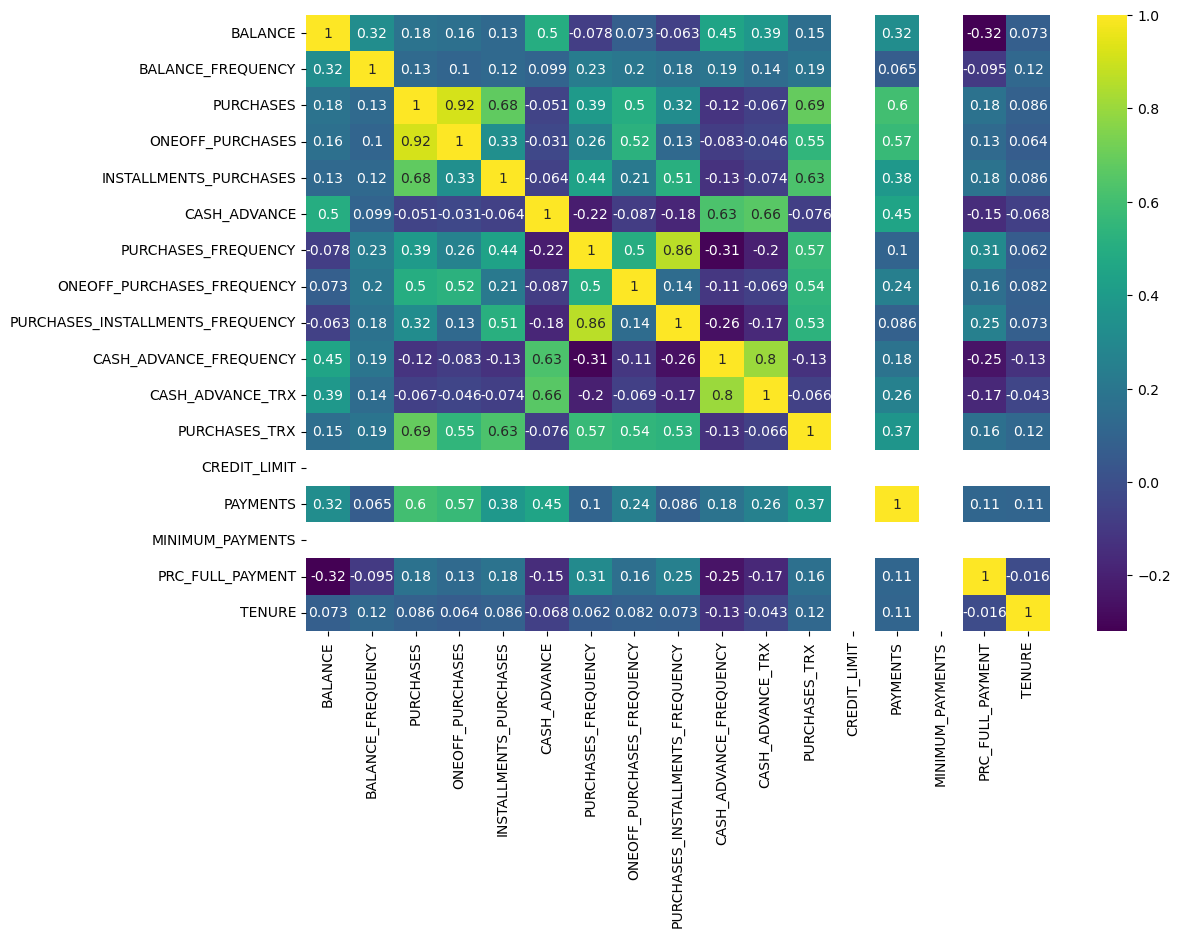

In [52]:
#Task 1.3
corr_matrix = df_scaled.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='viridis')

plt.show()

Dapat dilihat bahwa 3 fitur paling tinggi adalah:
1. ONEOFF_PURCHASES x PURCHASES dengan 0.92
2. PURCHASES_INSTALLMENTS_FREQUENCY x PURCHASES_FREQUENCY dengan 0.86
3. CASH_ADVANCE_FREQUENCY x CASH_ADVANCE_TRX dengan 0.8

**Task 2 — PCA dan Explained Variance**
1. Terapkan PCA pada data yang sudah di-scale. Fit PCA dengan n_components sama dengan jumlah fitur.
2. Plot scree plot: sumbu x adalah nomor komponen, sumbu y adalah explained variance ratio.
3. Tambahkan garis kumulatif explained variance. Tentukan jumlah komponen yang menjelaskan minimal 80% variance.
4. Buat dataset baru dengan komponen PCA terpilih (misalnya 4 atau 5 komponen). Dataset ini digunakan untuk Task 3.
5. Tuliskan jumlah komponen yang Anda pilih dan alasannya (1-2 kalimat).

In [53]:
#Task 2.1
pca = PCA(n_components=df_scaled.shape[1])

pca.fit(df_scaled)

explained_var   = pca.explained_variance_ratio_
cummulative_var = np.cumulative_sum(explained_var)

print("Explained Variance Ratio per komponen:")
for i, ev in enumerate(explained_var, 1):
    print(f"PC{i:02d}: {ev:.4f}")

Explained Variance Ratio per komponen:
PC01: 0.2986
PC02: 0.2128
PC03: 0.0974
PC04: 0.0797
PC05: 0.0654
PC06: 0.0597
PC07: 0.0441
PC08: 0.0375
PC09: 0.0318
PC10: 0.0262
PC11: 0.0182
PC12: 0.0138
PC13: 0.0117
PC14: 0.0031
PC15: 0.0000
PC16: 0.0000
PC17: 0.0000


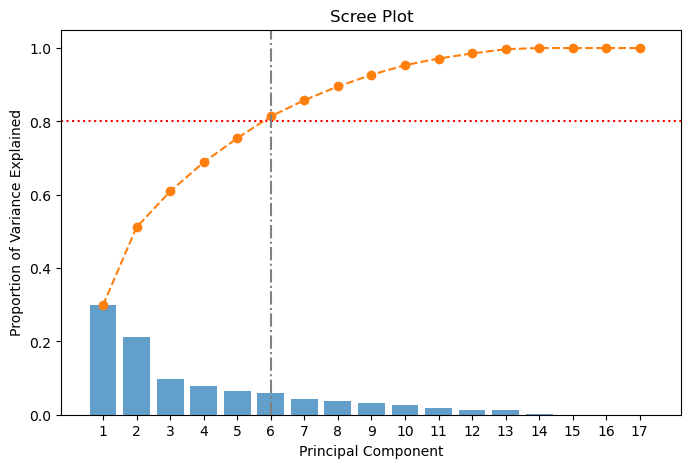

In [54]:
#Task 2.2 dan Task 2.3
n_components_80 = np.argmax(cummulative_var >= 0.80) + 1

plt.figure(figsize=(8, 5))

plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, label='Individual')
plt.plot(range(1, len(cummulative_var) + 1), cummulative_var, marker='o', linestyle='--', color='tab:orange', label='Cumulative')

plt.axhline(y=0.80, color='r', linestyle=':', label='80% Threshold')
plt.axvline(x=n_components_80, color='grey', linestyle='-.')

plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, len(explained_var) + 1))
plt.show()

In [55]:
#Task 2.4
pca_selected = PCA(n_components=n_components_80)
pca_features = pca_selected.fit_transform(df_scaled)

df_selected = pd.DataFrame(
    data=pca_features, 
    columns=[f'PC{i+1}' for i in range(n_components_80)]
)

df_selected

,PC1,PC2,PC3,PC4,PC5,PC6
0,-1.368546,-1.122520,-0.608813,-0.639829,0.457903,-0.221593
1,-1.624072,2.133346,-0.484152,0.344310,0.933186,0.603978
2,0.869600,-0.459678,-0.025883,-1.781366,-1.726986,1.001126
3,-1.047260,-0.393484,-1.510335,-0.686470,0.310291,-0.396354
4,-1.350652,-0.736023,-0.504742,-1.152392,0.146970,-0.033968
...,...,...,...,...,...,...
8945,0.119446,-1.744855,1.170888,2.777331,-2.529754,-1.514124
8946,-0.147089,-1.460585,1.287590,1.916942,-2.577778,-2.481304
8947,-0.482510,-1.654085,0.584256,2.460003,-2.456316,-2.026864
8948,-2.034755,-0.687007,-0.920046,2.043969,-2.595723,-1.857877


**#Task 2.5**\
Alasan memilih komponen tersebut sudah secara otomatis dengan rumus ```n_components_80 = np.argmax(cummulative_var >= 0.80) + 1``` sehingga menyesuaikan dengan data yang sudah dibuat.

**Task 3 — K-Means Clustering**
1. Jalankan K-Means untuk k = 2, 3, 4, 5, 6, 7, 8 pada dataset PCA dari Task 2.
2. Hitung inertia dan silhouette score untuk setiap nilai k. Tampilkan keduanya dalam dua subplot berdampingan.
3. Pilih nilai k terbaik berdasarkan grafik tersebut. Jelaskan pilihan Anda dalam 2-3 kalimat.
4. Latih ulang K-Means dengan k terpilih dan simpan label cluster ke kolom baru di dataframe asli.

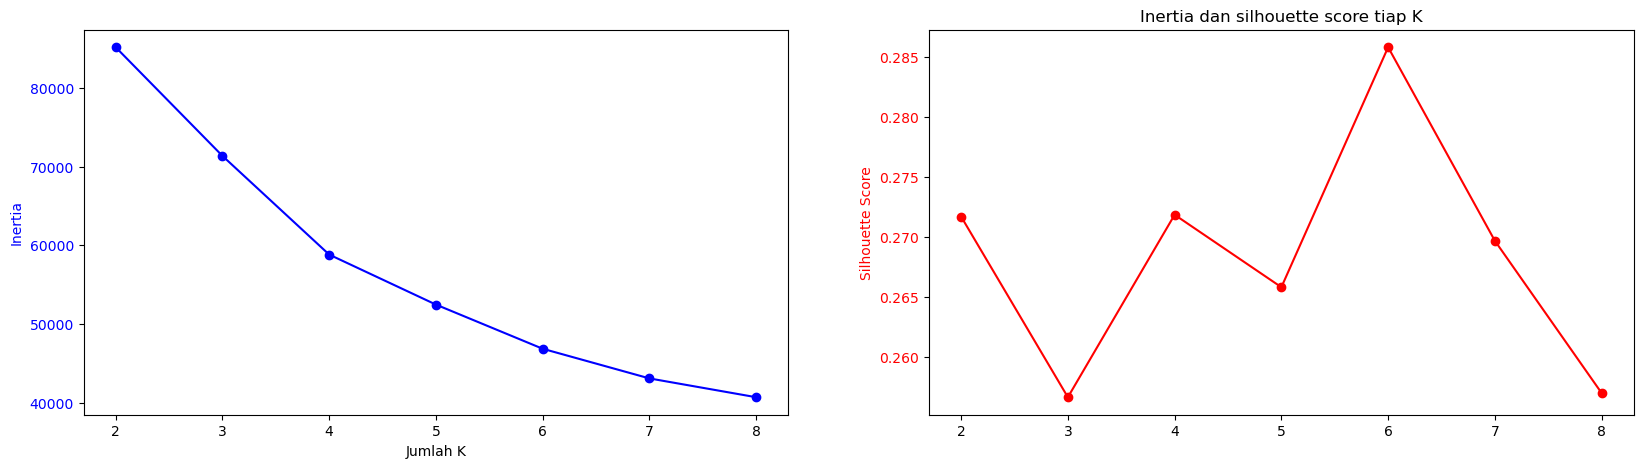

In [56]:
#Task 3.1 dan 3.2
k_range = range(2, 9)
inertia_list = []
silhouette_list = []

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_selected)

    inertia_list.append(kmeans.inertia_)

    silhouette_list.append(silhouette_score(df_selected, kmeans.labels_))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

ax1.plot(k_range, inertia_list, 'bo-', label='Inertia')
ax1.set_xlabel('Jumlah K')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2.plot(k_range, silhouette_list, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Inertia dan silhouette score tiap K')
plt.show()

**#Task 3.3**\
Dapat dilihat dari hasil inertia elbow method dan silhouette score di atas, K ter baik dipilih pada K = 6. Nilai K tersebut memilik i silhouette score yang paling mendekati dengan 1 dan terlihat dari inertia yang sudah mulai melandai.

In [57]:
#Task 3.4
kmeans_selected = KMeans(n_clusters=6)
labels = kmeans_selected.fit_predict(df_scaled)

df['cluster'] = labels

df.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,3000.0,201.802084,312.343947,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,3000.0,4103.032597,312.343947,0.222222,12,3
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,3000.0,622.066742,312.343947,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,3000.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,3000.0,678.334763,312.343947,0.000000,12,0


**Task 4 — Visualisasi dan Interpretasi Cluster**
1. Buat scatter plot 2D menggunakan dua komponen PCA pertama. Warnai titik berdasarkan label cluster.
2. Hitung rata-rata setiap fitur asli per cluster (gunakan groupby pada dataframe asli). Tampilkan sebagai tabel.
3. Untuk setiap cluster, tulis 2-3 kalimat profil pelanggannya: pola penggunaan kartu kredit seperti apa yang mendominasi cluster tersebut?
4. Berikan rekomendasi satu jenis promosi yang paling relevan untuk masing-masing cluster.

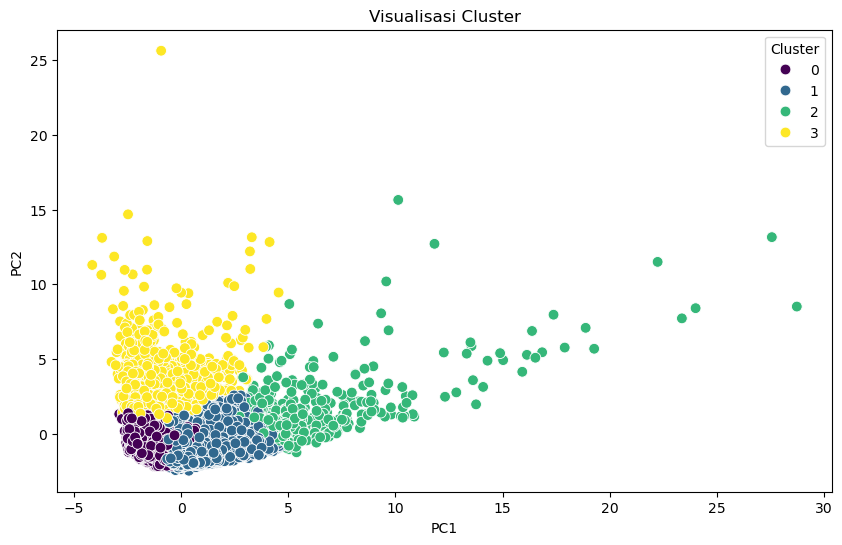

In [60]:
#Task 4.1
new_pca = PCA(n_components=2)
pca_data = new_pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60)
plt.title('Visualisasi Cluster')
plt.show()

In [63]:
#Task 4.2
cluster_profile = df.groupby('cluster').mean()

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,1038.823359,0.786106,281.422533,216.497179,65.193998,559.406823,0.177044,0.087754,0.085789,0.103899,1.878036,3.012652,3000.0,972.948252,312.343947,0.080655,11.467358
1,978.644827,0.938766,1282.313184,624.787096,657.798522,229.214081,0.890303,0.304128,0.717086,0.044526,0.826793,22.804662,3000.0,1384.379558,312.343947,0.266543,11.602243
2,3566.386802,0.987771,8143.134904,5414.214137,2730.564603,693.045117,0.951054,0.749535,0.792603,0.073537,2.235616,93.213699,3000.0,7688.740803,312.343947,0.294207,11.967123
3,4242.975313,0.966936,440.914622,283.863336,157.133014,4437.582558,0.260923,0.129359,0.163320,0.499351,14.499196,6.783762,3000.0,3350.878835,312.343947,0.037218,11.312701


**#Task 4.3**
1. Cluster 0: low activity user, memiliki balance yang sedang tetapi jarang melakukan pembelian. Selain itu, hampir jarang melakukan full payment sehingga menunjukkan aktivitas kartu kredit paling minimal.
2. Cluster 1: active user, merupakan pengguna aktif yang sering menggunakan kartu kredit untuk belanja. Selain itu, mereka lebih senang melakukan pembayaran menggunakan cicilan dibanding penarikan tunai.
3. Cluster 2: VIP user, pengguna aktif dengan pelaksanaan transaksi paling banyak dan besar. Menggunakan kartu kredit untuk daya beli yang jauh dari rata-rata cluster lainnya.
4. Cluster 3: Peminjam Tunai, pengguna aktif yang paling sering menarik tunai dengan kartu kredit. Mereka termasuk pengguna yang ketergantungan dengan kartu kredit jangka pendek dan membuat utang paling banyak.

**#Task 4.4**
1. Cluster 0: low activity user, memberikan voucher discount untuk mendorong aktivitas penggunaan kartu dalam transaksi sehari-hari.
2. Cluster 1: active user, memberikan program cicilan 0% dengan waktu tenor diperpanjang.
3. Cluster 2: VIP user, memberikan gaya hidup eksklusif seperti VIP membership pada kebutuhan/area tertentu, seperti restoran, lounge bandara, atau VIP customer service.
4. Cluster 3: Peminjam Tunai, mengubah utang menjadi cicilan.